Data Augmentation

In [ ]:
import os
import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shutil
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

In [ ]:
if not os.path.exists("cropped_dataset"):
    os.makedirs("cropped_dataset")

face_cascade = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")

for face_folder in os.listdir("database"):
    print(f"Checking for faces in folder {face_folder}")
    image_list = os.listdir(os.path.join("database", face_folder))
    for image in image_list:
        # plt.figure(figsize=(2, 2))
        img = cv2.imread(os.path.join(f"database/{face_folder}/{image}"))
        # print(f"Shape of input image is {img.shape}")
        # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        
        img_small = cv2.resize(img, None, fx = 0.8, fy = 0.8, interpolation=cv2.INTER_AREA)
        # print(f"Shape of scaled down image is {img_small.shape}")

        face = face_cascade.detectMultiScale(img_small, 1.05, 7)

        if len(face) == 0:
            print(f"No face detected in {face_folder}/{image}")
            continue

        x, y, w, h = max(face, key = lambda b: b[2] * b[3])

        
    



    #     cv2.rectangle(img, (x-300, y-300), (x+w+300, y+h+300), (255, 0, 0), 2)
    #     plt.imshow(img)

    #     break
    # break
        crop = 300
        x1 = max(0, x-300)
        y1 = max(0, y-crop)
        x2 = min(img_small.shape[1], x+w+crop)
        y2 = min(img_small.shape[0], y+h+crop)

        crop_img = img_small[y1:y2, x1:x2]

        if crop_img.size == 0:
            print("empty crop")
            continue
        
        # print(f"Shape of cropped image is {crop_img.shape}")
        crop_img = cv2.resize(crop_img, (128, 128), interpolation=cv2.INTER_AREA)
        # plt.imshow(crop_img)

        if not os.path.exists(f"cropped_dataset/{face_folder}"):
            os.makedirs(f"cropped_dataset/{face_folder}")
        save_path = os.path.join("cropped_dataset", face_folder, image)
        cv2.imwrite(save_path, crop_img)
        
    print(f"Completed folder {face_folder}")
    

Create train and test set

In [2]:
if not os.path.exists("train"):
    os.makedirs("train")
if not os.path.exists("test"):
    os.makedirs("test")
data_path = "cropped_dataset"
classes = os.listdir(data_path)
for face_folder in classes:
    images_list = os.listdir(os.path.join(data_path, face_folder))

    train_path = os.path.join("train", face_folder)
    test_path = os.path.join("test", face_folder)

    os.makedirs(train_path, exist_ok=True)
    os.makedirs(test_path, exist_ok=True)

    train_set, test_set = train_test_split(images_list, test_size=0.2, random_state=42)

    for img in train_set:
        
        src = os.path.join(data_path, face_folder, img)
        dest = os.path.join(train_path, img)

        shutil.copy(src, dest)

    for img in test_set:

        src = os.path.join(data_path, face_folder, img)
        dest = os.path.join(test_path, img)

        shutil.copy(src, dest)

    


Applying augmentations to the dataset using albumentations

In [3]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussianBlur(blur_limit=3, p=0.5),
    A.GaussNoise(std_range=[0.05, 0.1],p=0.2)
])

In [4]:
augmentations = 10

for face_folder in os.listdir("train"):
    print(f"Reading images from {face_folder}")
    image_list = os.listdir(os.path.join("train", face_folder))
    for image in image_list:
        # plt.figure(figsize=(2, 2))
        img = cv2.imread(os.path.join(f"train/{face_folder}/{image}"), cv2.IMREAD_GRAYSCALE)
        # print(f"Shape of input image is {img.shape}")
        # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        save_path = os.path.join("train", face_folder)
        
        for i in range(augmentations):
            augmented = transform(image = img)
            augm_img = augmented["image"]
            cv2.imwrite(f"{save_path}/{image}_aug_{i}.jpg", augm_img)
            

Reading images from Aswin Tom
Reading images from Mahin Kalandar Sha
Reading images from Sandra
Reading images from Abhijith HR
Reading images from Mohammed Farhan Z
Reading images from Deepu P
Reading images from Aleena Mol
Reading images from Bhavya Mohan
Reading images from Ashima Shibu
Reading images from Revathy RK
Reading images from Hrishikesh M Jayakrishnan
Reading images from Sneha S
Reading images from Soya
Reading images from Govind Sankar VG
Reading images from Sreelakshmi L


In [5]:
augmentations = 10

for face_folder in os.listdir("test"):
    print(f"Reading images from {face_folder}")
    image_list = os.listdir(os.path.join("test", face_folder))
    for image in image_list:
        # plt.figure(figsize=(2, 2))
        img = cv2.imread(os.path.join(f"test/{face_folder}/{image}"), cv2.IMREAD_GRAYSCALE)
        # print(f"Shape of input image is {img.shape}")
        # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        save_path = os.path.join("test", face_folder)
        
        for i in range(augmentations):
            augmented = transform(image = img)
            augm_img = augmented["image"]
            cv2.imwrite(f"{save_path}/{image}_aug_{i}.jpg", augm_img)
            

Reading images from Aswin Tom
Reading images from Mahin Kalandar Sha
Reading images from Sandra
Reading images from Abhijith HR
Reading images from Mohammed Farhan Z
Reading images from Deepu P
Reading images from Aleena Mol
Reading images from Bhavya Mohan
Reading images from Ashima Shibu
Reading images from Revathy RK
Reading images from Hrishikesh M Jayakrishnan
Reading images from Sneha S
Reading images from Soya
Reading images from Govind Sankar VG
Reading images from Sreelakshmi L


In [6]:
train_data = []
train_labels = []
data_path = "train"
classes = os.listdir(data_path)
for face_folder in classes:
    for face in os.listdir(os.path.join(data_path, face_folder)):
        image = cv2.imread(os.path.join(data_path, f"{face_folder}/{face}"), cv2.IMREAD_GRAYSCALE)
        
        image_flattened = image.flatten() / 255.0
        train_data.append(image_flattened)
        train_labels.append(classes.index(face_folder))

In [7]:
classes[8]

'Ashima Shibu'

In [8]:
len(train_data)

1947

In [9]:
test_data = []
test_labels = []
data_path = "test"
classes = os.listdir(data_path)
for face_folder in classes:
    for face in os.listdir(os.path.join(data_path, face_folder)):
        image = cv2.imread(os.path.join(data_path, f"{face_folder}/{face}"), cv2.IMREAD_GRAYSCALE)
        
        image_flattened = image.flatten() / 255.0
        test_data.append(image_flattened)
        test_labels.append(classes.index(face_folder))

In [10]:
train_df = pd.DataFrame(train_data)
train_df["label"] = train_labels

test_df = pd.DataFrame(test_data)
test_df["label"] = test_labels

In [11]:
train_df

,0,1,2,3,4,5,6,7,8,9,...,16375,16376,16377,16378,16379,16380,16381,16382,16383,label
0,0.717647,0.709804,0.694118,0.662745,0.623529,0.588235,0.545098,0.498039,0.454902,0.407843,...,0.643137,0.647059,0.647059,0.650980,0.647059,0.639216,0.635294,0.631373,0.627451,0
1,0.000000,0.003922,0.000000,0.000000,0.000000,0.003922,0.003922,0.000000,0.000000,0.003922,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
2,0.003922,0.000000,0.000000,0.000000,0.000000,0.000000,0.003922,0.000000,0.000000,0.000000,...,0.003922,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
3,0.003922,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003922,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
4,0.000000,0.007843,0.000000,0.011765,0.031373,0.074510,0.043137,0.003922,0.007843,0.290196,...,0.000000,0.000000,0.015686,0.000000,0.003922,0.000000,0.043137,0.035294,0.003922,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1942,0.552941,0.556863,0.611765,0.686275,0.572549,0.498039,0.317647,0.247059,0.270588,0.360784,...,0.407843,0.325490,0.247059,0.286275,0.325490,0.329412,0.294118,0.349020,0.364706,14
1943,0.117647,0.117647,0.121569,0.117647,0.121569,0.121569,0.109804,0.121569,0.113725,0.117647,...,0.113725,0.113725,0.117647,0.117647,0.121569,0.109804,0.125490,0.109804,0.121569,14
1944,0.388235,0.435294,0.603922,0.709804,0.650980,0.568627,0.654902,0.686275,0.549020,0.462745,...,0.345098,0.227451,0.200000,0.168627,0.168627,0.149020,0.345098,0.415686,0.266667,14
1945,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.160784,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14


In [ ]:
# from cuml import PCA
# from cuml.model_selection import train_test_split
# import cupy as cp

In [12]:
x_train = train_df.drop("label", axis = 1).values
# x_train_gpu = cp.asarray(x_train)

y_train = train_df["label"].values
# y_train_gpu = cp.asarray(y_train)

x_test = test_df.drop("label", axis = 1).values
# x_test_gpu = cp.asarray(x_test)

y_test = test_df["label"].values
# y_test_gpu = cp.asarray(y_test)



In [13]:
y_test

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  6,
        6,  6,  6,  6,  6

In [14]:
pca = PCA(0.95)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

Final KNN model

In [29]:
knn_final = KNeighborsClassifier(n_neighbors=2, metric="manhattan")
knn_final.fit(x_train_pca, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",2
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [30]:
y_pred_final = knn_final.predict(x_test_pca)

conf_mat = confusion_matrix(y_test, y_pred_final)

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.84      0.98      0.91        44
           1       0.89      1.00      0.94        33
           2       0.92      1.00      0.96        33
           3       0.93      0.76      0.83        33
           4       0.97      0.91      0.94        33
           5       0.98      0.98      0.98        44
           6       0.69      0.82      0.75        33
           7       0.68      0.82      0.74        44
           8       0.74      0.61      0.67        33
           9       0.56      0.73      0.63        33
          10       0.94      0.68      0.79        44
          11       1.00      0.91      0.95        33
          12       1.00      1.00      1.00        33
          13       1.00      0.98      0.99        44
          14       0.79      0.58      0.67        33

    accuracy                           0.85       550
   macro avg       0.86      0.85      0.85       550
weighted avg       0.86   

Text(0.5, 1.0, 'Confusion matrix')

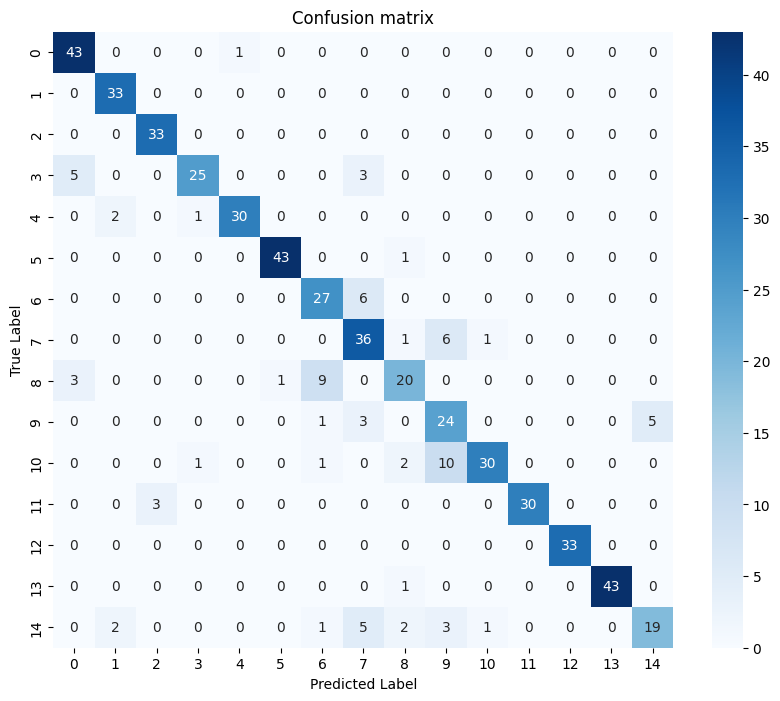

In [31]:
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion matrix")


In [ ]:
import joblib

joblib.dump(knn_final, 'face_recog.pkl')
